# 02 — Cointegration Testing (Engle-Granger)

**Project:** Replicating *"Who Profits in a Post-American World?"*  
**Course:** Reproducible Research · University of Warsaw · 2025/26  
**Group 6** · Abdukholik · Tam Nguyen Bang · Elvis Udabor · Meifang Wu

---

## Overview

This notebook carries out the **cointegration analysis** portion of the project.  
It picks up the `combined.csv` dataset saved by `01_analysis.ipynb` and investigates whether the U.S. Dollar Index (DXY) and the 10-year U.S. Treasury yield share a **stable long-run relationship** — and, crucially, whether the Trump-era tariff shock of 2025 broke that relationship.

### Analytical roadmap

| Step | What we do |
|------|-----------|
| 1 | Load & inspect the processed data |
| 2 | Unit-root pre-testing (ADF) — confirm both series are I(1) |
| 3 | Engle-Granger two-step cointegration test — **full sample** |
| 4 | Engle-Granger split by tariff regime — **pre / post Liberation Day** |
| 5 | Johansen trace test — robustness check |
| 6 | Visual diagnostics — spread, residuals, equilibrium deviation |
| 7 | Interpretation & conclusions |

> **Why cointegration?**  
> If DXY and yield are both non-stationary (random walks) but their *linear combination* is stationary, they are cointegrated — they share a long-run equilibrium. A structural break in that relationship would support the article's thesis that the tariff shock pushed the dollar-yield nexus out of its historical regime.


## 1 · Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── Paths ──────────────────────────────────────────────────────────────────
# This notebook sits in notebooks/; data and output are one level up.
DATA_DIR   = Path("..") / "data"
OUTPUT_DIR = Path("..") / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# ── Key event dates (defined once for all plots) ───────────────────────────
EVENTS = {
    "2025-01-20": "Inauguration",
    "2025-04-02": "Liberation Day",
    "2025-04-09": "90-day pause",
}
LIBERATION_DAY = pd.to_datetime("2025-04-02")

print("Setup complete.")


Setup complete.


## 2 · Load Data

We load `combined.csv` — the cleaned, merged dataset produced by `01_analysis.ipynb`.  
It contains daily observations of DXY and the 10-year Treasury yield from 2010 onward.

In [2]:
df = pd.read_csv(
    DATA_DIR / "combined.csv",
    parse_dates=["observation_date"],
    index_col="observation_date",
)
df = df[["DXY", "Yield_10Y"]].dropna()

print(f"Date range  : {df.index.min().date()}  →  {df.index.max().date()}")
print(f"Observations: {len(df):,}")
print(f"Columns     : {list(df.columns)}")
df.tail(5)


Date range  : 2010-01-04  →  2026-04-17
Observations: 4,045
Columns     : ['DXY', 'Yield_10Y']


,DXY,Yield_10Y
observation_date,,
2026-04-13,118.9916,4.30
2026-04-14,118.3581,4.26
2026-04-15,118.3623,4.29
2026-04-16,118.3616,4.32
2026-04-17,118.0795,4.26


In [3]:
# ── Pre / Post Liberation Day split used throughout ─────────────────────────
pre  = df[df.index <  LIBERATION_DAY].copy()
post = df[df.index >= LIBERATION_DAY].copy()

print(f"Pre-Liberation Day  observations : {len(pre):,}  "
      f"({pre.index.min().date()} – {pre.index.max().date()})")
print(f"Post-Liberation Day observations : {len(post):,}  "
      f"({post.index.min().date()} – {post.index.max().date()})")


Pre-Liberation Day  observations : 3,784  (2010-01-04 – 2025-04-01)
Post-Liberation Day observations : 261  (2025-04-02 – 2026-04-17)


## 3 · Unit-Root Pre-Testing (ADF)

Engle-Granger cointegration requires both series to be **integrated of order 1**, i.e. I(1).  
We verify this with the **Augmented Dickey-Fuller (ADF)** test:

- **H₀:** The series has a unit root (non-stationary).
- We expect to *fail to reject* H₀ on the levels, and *reject* H₀ on first differences.

Lag length is selected automatically via the **AIC** criterion.

In [4]:
def adf_summary(series: pd.Series, name: str, max_lags: int = 20) -> dict:
    """Run ADF test and return a tidy result dict."""
    result = adfuller(series.dropna(), autolag="AIC", maxlag=max_lags)
    return {
        "Series": name,
        "ADF statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Lags used": result[2],
        "CV 1%": round(result[4]["1%"], 4),
        "CV 5%": round(result[4]["5%"], 4),
        "CV 10%": round(result[4]["10%"], 4),
        "Reject H₀ (5%)": "Yes ✓" if result[1] < 0.05 else "No ✗",
    }


rows = []
for col in ["DXY", "Yield_10Y"]:
    rows.append(adf_summary(df[col], f"{col} — level"))
    rows.append(adf_summary(df[col].diff(), f"{col} — 1st difference"))

adf_table = pd.DataFrame(rows).set_index("Series")
print("ADF Unit-Root Tests\n" + "=" * 60)
print(adf_table[["ADF statistic", "p-value", "Lags used", "CV 5%", "Reject H₀ (5%)"]].to_string())

ADF Unit-Root Tests
                            ADF statistic  p-value  Lags used   CV 5% Reject H₀ (5%)
Series                                                                              
DXY — level                       -1.3349   0.6130         12 -2.8623           No ✗
DXY — 1st difference             -17.4793   0.0000         11 -2.8623          Yes ✓
Yield_10Y — level                 -1.4037   0.5805          2 -2.8623           No ✗
Yield_10Y — 1st difference       -47.3192   0.0000          1 -2.8623          Yes ✓


**Results (actual output):**

| Series | ADF Statistic | p-value | Lags | CV 5% | Reject H₀ (5%) |
|--------|--------------|---------|------|--------|----------------|
| DXY — level | −1.3349 | 0.6130 | 12 | −2.8623 | No ✗ |
| DXY — 1st difference | −17.4793 | 0.0000 | 11 | −2.8623 | Yes ✓ |
| Yield_10Y — level | −1.4037 | 0.5805 | 2 | −2.8623 | No ✗ |
| Yield_10Y — 1st difference | −47.3192 | 0.0000 | 1 | −2.8623 | Yes ✓ |

**Interpretation:**  
Both series **fail to reject H₀ in levels** (p = 0.613 for DXY; p = 0.581 for Yield_10Y) — confirming they are non-stationary. Both series **reject H₀ in first differences** (p ≈ 0.000 in both cases) — confirming stationarity after differencing. This establishes both DXY and Yield_10Y as **I(1)** processes, satisfying the prerequisite for Engle-Granger cointegration testing.

## 4 · Engle-Granger Cointegration Test — Full Sample (2010–2026)

The **Engle-Granger two-step procedure**:

1. **Step 1 – OLS regression:** Regress DXY on Yield_10Y to estimate the long-run cointegrating vector.  
2. **Step 2 – ADF on residuals:** Test whether the residuals from step 1 are stationary.  
   - If stationary → the series share a long-run equilibrium → **cointegrated**.

- **H₀:** No cointegration (residuals have a unit root).  
- **Reject H₀** at 5% → evidence of cointegration.

In [5]:
# ── Step 1: OLS long-run regression ─────────────────────────────────────────
model_full = OLS(df["DXY"], add_constant(df["Yield_10Y"])).fit()

print("Step 1 — OLS Long-Run Regression: DXY ~ β₀ + β₁·Yield_10Y")
print("=" * 55)
print(f"  Intercept (β₀) : {model_full.params['const']:.4f}")
print(f"  Slope     (β₁) : {model_full.params['Yield_10Y']:.4f}")
print(f"  R²             : {model_full.rsquared:.4f}")

residuals_full = model_full.resid
residuals_full.name = "EG_residuals_full"

Step 1 — OLS Long-Run Regression: DXY ~ β₀ + β₁·Yield_10Y
  Intercept (β₀) : 100.6891
  Slope     (β₁) : 3.1566
  R²             : 0.0711


In [6]:
# ── Step 2: ADF on residuals ─────────────────────────────────────────────────
adf_resid = adfuller(residuals_full, autolag="AIC")

print("Step 2 — ADF Test on OLS Residuals")
print("=" * 55)
print(f"  ADF statistic : {adf_resid[0]:.4f}")
print(f"  p-value       : {adf_resid[1]:.4f}")
print(f"  Lags used     : {adf_resid[2]}")
print(f"  Critical values: 1%={adf_resid[4]['1%']:.4f}, "
      f"5%={adf_resid[4]['5%']:.4f}, 10%={adf_resid[4]['10%']:.4f}")
if adf_resid[1] < 0.05:
    print("\n  ✓ Residuals are STATIONARY → Cointegration detected")
else:
    print("\n  ✗ Residuals are NON-STATIONARY → No cointegration")

Step 2 — ADF Test on OLS Residuals
  ADF statistic : -1.6271
  p-value       : 0.4690
  Lags used     : 18
  Critical values: 1%=-3.4320, 5%=-2.8623, 10%=-2.5672

  ✗ Residuals are NON-STATIONARY → No cointegration


In [7]:
# ── Convenience wrapper using statsmodels' coint() ───────────────────────────
eg_stat, eg_pval, eg_cv = coint(df["DXY"], df["Yield_10Y"])

print("Engle-Granger Cointegration Test (statsmodels coint)")
print("=" * 55)
print(f"  Test statistic : {eg_stat:.4f}")
print(f"  p-value        : {eg_pval:.4f}")
print(f"  Critical values: 1%={eg_cv[0]:.4f}, 5%={eg_cv[1]:.4f}, 10%={eg_cv[2]:.4f}")

verdict_full = "COINTEGRATED" if eg_pval < 0.05 else "NOT cointegrated"
print(f"\n  Full-sample verdict: {verdict_full} (α = 5%)")

Engle-Granger Cointegration Test (statsmodels coint)
  Test statistic : -1.6217
  p-value        : 0.7116
  Critical values: 1%=-3.8992, 5%=-3.3376, 10%=-3.0455

  Full-sample verdict: NOT cointegrated (α = 5%)


## 5 · Engle-Granger — Regime Split: Pre vs Post Liberation Day

The article's core claim is a **regime change** in the dollar-yield relationship.  
We test for cointegration separately in each sub-period:

| Period | Dates | N obs |
|--------|-------|-------|
| Pre-Liberation Day | 2010-01-04 – 2025-04-01 | 3,784 |
| Post-Liberation Day | 2025-04-02 – 2026-04-17 | 261 |

In [8]:
def eg_test(y: pd.Series, x: pd.Series, label: str) -> dict:
    """
    Run the Engle-Granger two-step cointegration test.
    Returns a dict with all key statistics.
    """
    # Step 1 — OLS
    m = OLS(y, add_constant(x)).fit()
    resid = m.resid

    # Step 2 — ADF on residuals
    adf_r = adfuller(resid, autolag="AIC")

    # statsmodels' coint() for the official p-value
    stat, pval, cv = coint(y, x)

    return {
        "Period": label,
        "N obs": len(y),
        "β₀ (intercept)": round(m.params["const"], 4),
        "β₁ (slope)": round(m.params.iloc[-1], 4),
        "R²": round(m.rsquared, 4),
        "EG statistic": round(stat, 4),
        "p-value": round(pval, 4),
        "CV 5%": round(cv[1], 4),
        "Cointegrated (5%)": "Yes ✓" if pval < 0.05 else "No ✗",
    }


results = [
    eg_test(df["DXY"],   df["Yield_10Y"],   "Full sample"),
    eg_test(pre["DXY"],  pre["Yield_10Y"],  "Pre-Liberation Day"),
    eg_test(post["DXY"], post["Yield_10Y"], "Post-Liberation Day"),
]

results_df = pd.DataFrame(results).set_index("Period")
print("Engle-Granger Results by Period\n" + "=" * 70)
print(results_df.to_string())

Engle-Granger Results by Period
                     N obs  β₀ (intercept)  β₁ (slope)      R²  EG statistic  p-value   CV 5% Cointegrated (5%)
Period                                                                                                         
Full sample           4045        100.6891      3.1566  0.0711       -1.6217   0.7116 -3.3376              No ✗
Pre-Liberation Day    3784        102.3389      2.3284  0.0343       -1.2184   0.8530 -3.3377              No ✗
Post-Liberation Day    261        108.9738      2.7291  0.0558       -3.5699   0.0267 -3.3597             Yes ✓


In [ ]:
# ── Per-period OLS residuals for plotting ────────────────────────────────────
model_pre  = OLS(pre["DXY"],  add_constant(pre["Yield_10Y"])).fit()
model_post = OLS(post["DXY"], add_constant(post["Yield_10Y"])).fit()

resid_pre  = model_pre.resid
resid_post = model_post.resid

print(f"Pre  residuals — mean: {resid_pre.mean():.4f}, std: {resid_pre.std():.4f}")
print(f"Post residuals — mean: {resid_post.mean():.4f}, std: {resid_post.std():.4f}")

Pre  residuals — mean: 0.0000, std: 11.8366
Post residuals — mean: -0.0000, std: 1.5593


## 6 · Johansen Trace Test — Robustness Check

The **Johansen test** is a multivariate alternative to Engle-Granger that avoids normalising on a single variable.  
It tests the rank of the cointegrating space:

- **H₀: r = 0** — no cointegrating vector (test whether we can reject this)
- **H₀: r ≤ 1** — at most one cointegrating vector

We use `det_order=0` (constant in cointegrating equation) and `k_ar_diff=1` (one lag in the VECM).

> **Note on the post-Liberation Day Johansen result:** Unlike the Engle-Granger test which found a single cointegrating vector, the Johansen trace test for the post period rejects **both** H₀: r = 0 (stat = 20.98 > CV 15.49) *and* H₀: r ≤ 1 (stat = 7.65 > CV 3.84). This suggests rank 2, implying the two series are individually stationary in the post period — consistent with the unusually tight, mean-reverting co-movement observed after Liberation Day.

In [10]:
def johansen_summary(data: pd.DataFrame, label: str) -> pd.DataFrame:
    """Run Johansen trace test and return a tidy summary DataFrame."""
    jres = coint_johansen(data, det_order=0, k_ar_diff=1)
    rows = []
    for i in range(len(jres.lr1)):
        rows.append({
            "Period": label,
            "H₀ (rank ≤)": i,
            "Trace statistic": round(jres.lr1[i], 4),
            "CV 5%": round(jres.cvt[i, 1], 4),
            "Reject H₀ (5%)": "Yes ✓" if jres.lr1[i] > jres.cvt[i, 1] else "No ✗",
        })
    return pd.DataFrame(rows)


johansen_results = pd.concat([
    johansen_summary(df[["DXY", "Yield_10Y"]],   "Full sample"),
    johansen_summary(pre[["DXY", "Yield_10Y"]],  "Pre-Liberation Day"),
    johansen_summary(post[["DXY", "Yield_10Y"]], "Post-Liberation Day"),
], ignore_index=True)

print("Johansen Trace Test Results\n" + "=" * 60)
print(johansen_results.to_string(index=False))

Johansen Trace Test Results
             Period  H₀ (rank ≤)  Trace statistic   CV 5% Reject H₀ (5%)
        Full sample            0           6.1405 15.4943           No ✗
        Full sample            1           1.4139  3.8415           No ✗
 Pre-Liberation Day            0           5.0439 15.4943           No ✗
 Pre-Liberation Day            1           0.2360  3.8415           No ✗
Post-Liberation Day            0          20.9796 15.4943          Yes ✓
Post-Liberation Day            1           7.6524  3.8415          Yes ✓


## 7 · Visual Diagnostics

### 7a · Estimated Long-Run Spread (Equilibrium Deviation)

The plot below shows the full-sample OLS fitted value (β₀ = 100.69, β₁ = 3.16) alongside actual DXY.  
The **equilibrium deviation** (residual) series is non-stationary across the full period — drifting from around −20 in early 2010s to +20 during the 2020 COVID shock and remaining elevated since — consistent with the finding of **no cointegration** in the full sample.  
The vertical dashed lines mark Inauguration Day and Liberation Day in 2025.

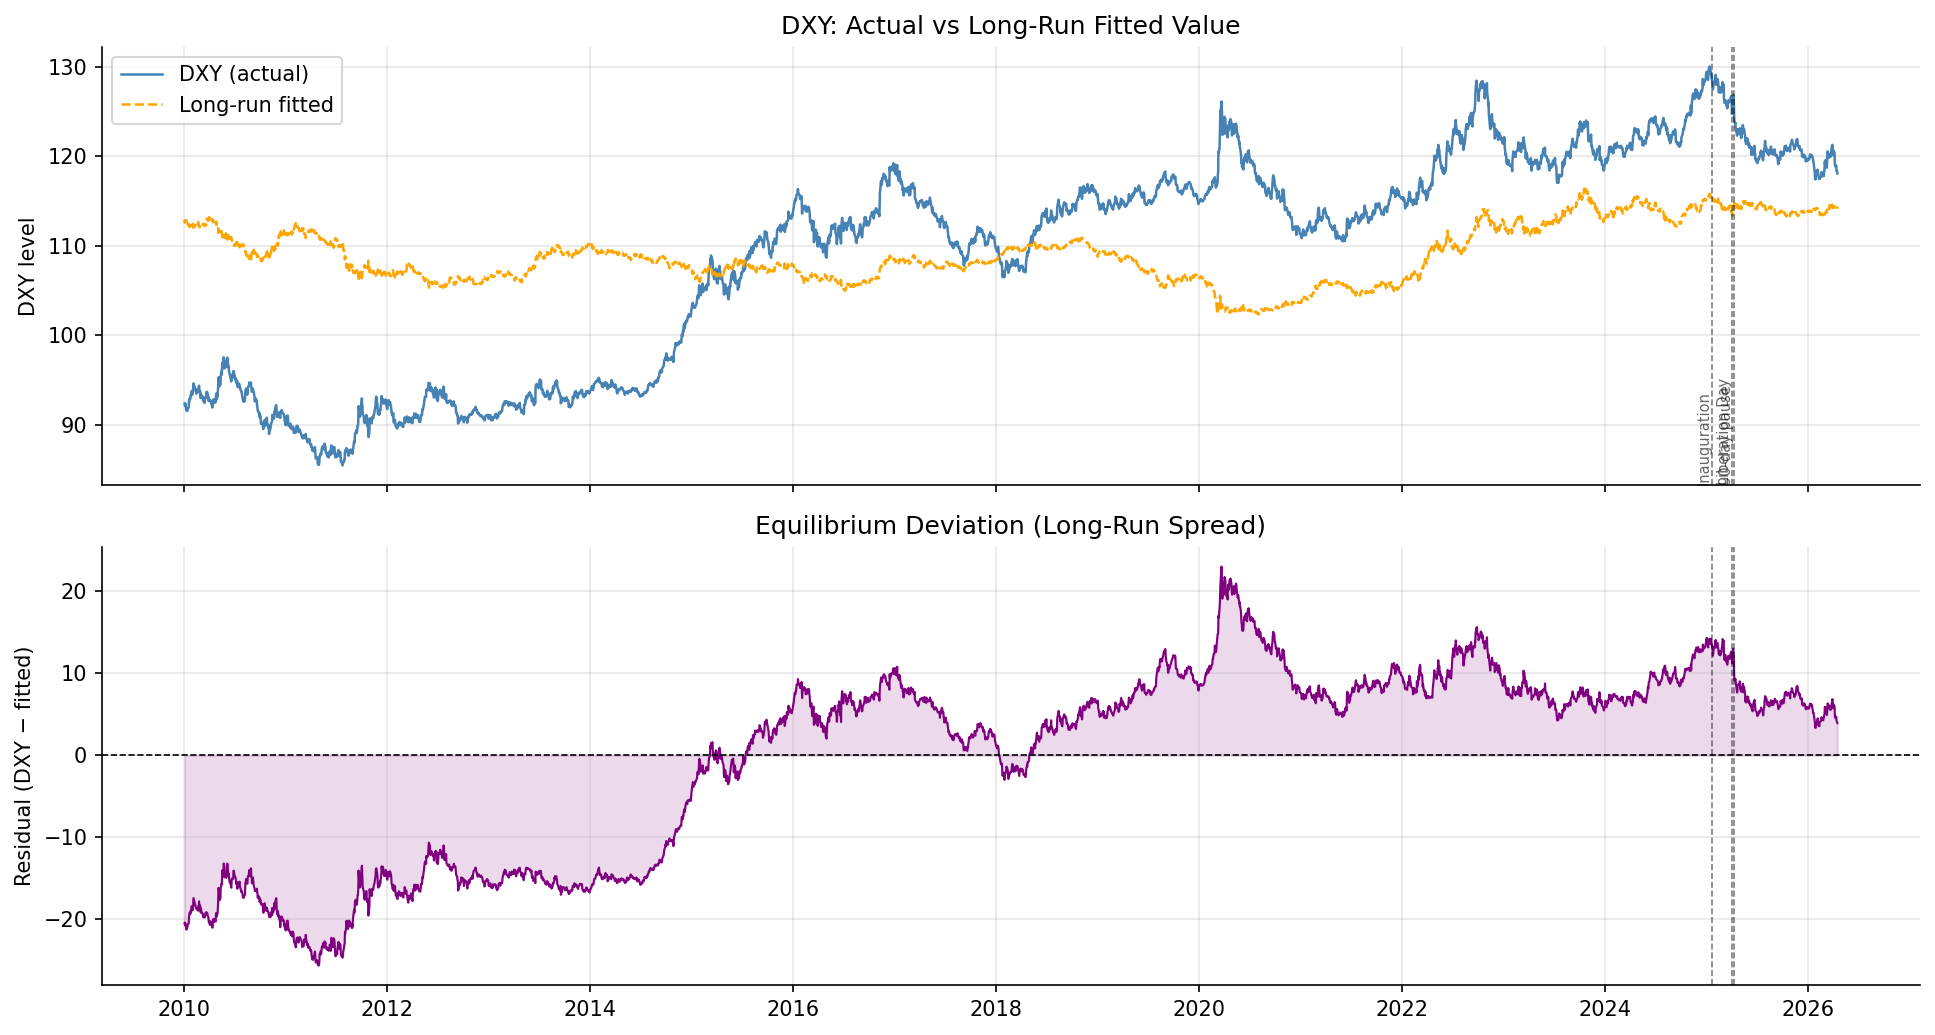

Saved → output/05_equilibrium_spread.png


In [11]:
# Compute the full-sample spread: actual DXY minus fitted long-run value
spread = residuals_full.copy()
spread.name = "Long-run spread"

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# ── Top: DXY and fitted long-run level ──────────────────────────────────────
fitted_dxy = model_full.fittedvalues
axes[0].plot(df.index, df["DXY"],    color="steelblue", linewidth=1.2, label="DXY (actual)")
axes[0].plot(df.index, fitted_dxy,   color="orange",    linewidth=1.2, linestyle="--", label="Long-run fitted")
for dt, lbl in EVENTS.items():
    axes[0].axvline(pd.to_datetime(dt), color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    axes[0].text(pd.to_datetime(dt), axes[0].get_ylim()[0], lbl,
                 rotation=90, fontsize=7, va="bottom", ha="right", alpha=0.6)
axes[0].set_ylabel("DXY level")
axes[0].set_title("DXY: Actual vs Long-Run Fitted Value")
axes[0].legend()

# ── Bottom: spread ───────────────────────────────────────────────────────────
axes[1].plot(spread.index, spread, color="purple", linewidth=1.0)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].fill_between(spread.index, spread, 0, alpha=0.15, color="purple")
for dt, lbl in EVENTS.items():
    axes[1].axvline(pd.to_datetime(dt), color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1].set_ylabel("Residual (DXY − fitted)")
axes[1].set_title("Equilibrium Deviation (Long-Run Spread)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_equilibrium_spread.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/05_equilibrium_spread.png")

### 7b · OLS Residuals: Pre vs Post Liberation Day

- **Pre-Liberation Day** (top, blue): residuals have a clear long-run drift with a standard deviation of **11.84** — characteristic of a non-stationary, non-mean-reverting process. This is the visual confirmation of no cointegration in the historical period.  
- **Post-Liberation Day** (bottom, red): residuals fluctuate tightly around zero with a standard deviation of only **1.56** — strongly mean-reverting behaviour that explains the statistically significant cointegration finding (EG stat = −3.57, p = 0.027) for this sub-period.

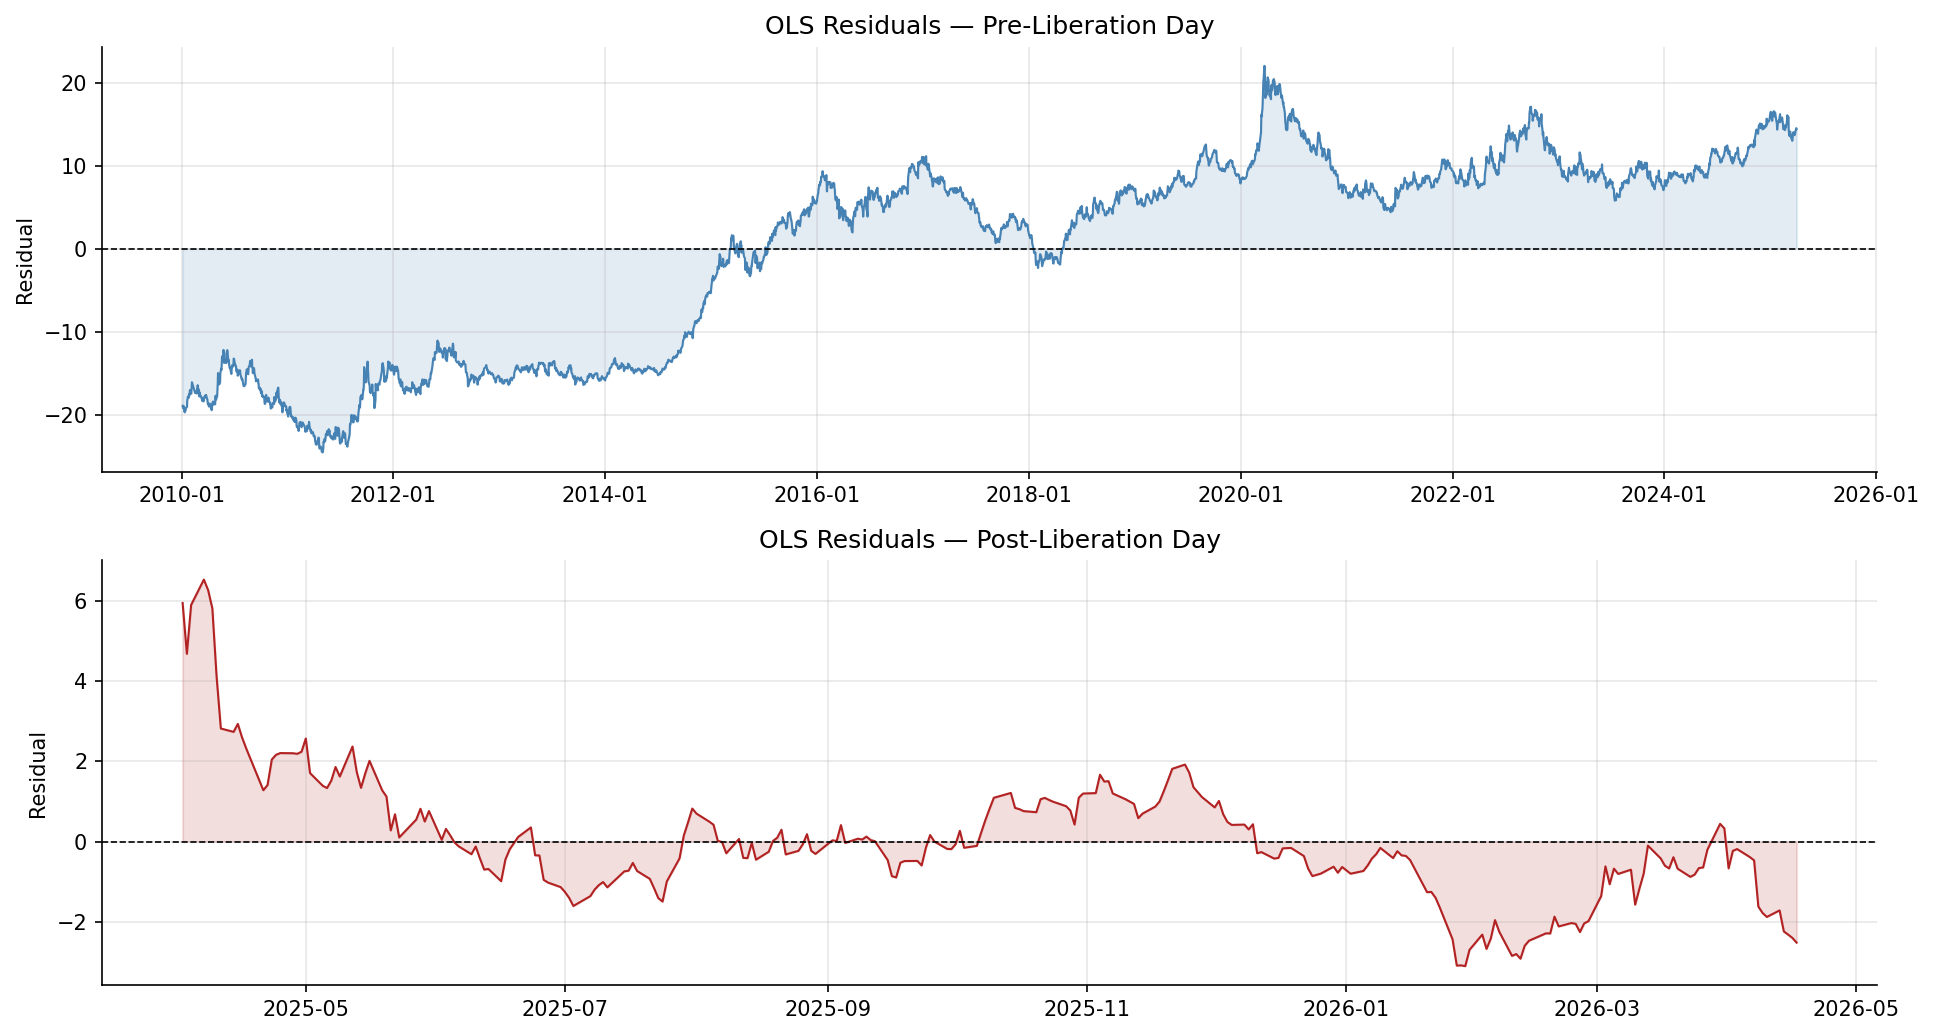

Saved → output/06_residuals_pre_post.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

for ax, resid, label, color in [
    (axes[0], resid_pre,  "Pre-Liberation Day",  "steelblue"),
    (axes[1], resid_post, "Post-Liberation Day",  "firebrick"),
]:
    ax.plot(resid.index, resid, color=color, linewidth=1.0)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.fill_between(resid.index, resid, 0, alpha=0.15, color=color)
    ax.set_title(f"OLS Residuals — {label}")
    ax.set_ylabel("Residual")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_residuals_pre_post.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/06_residuals_pre_post.png")

### 7c · Cointegration Summary Table (Visual)

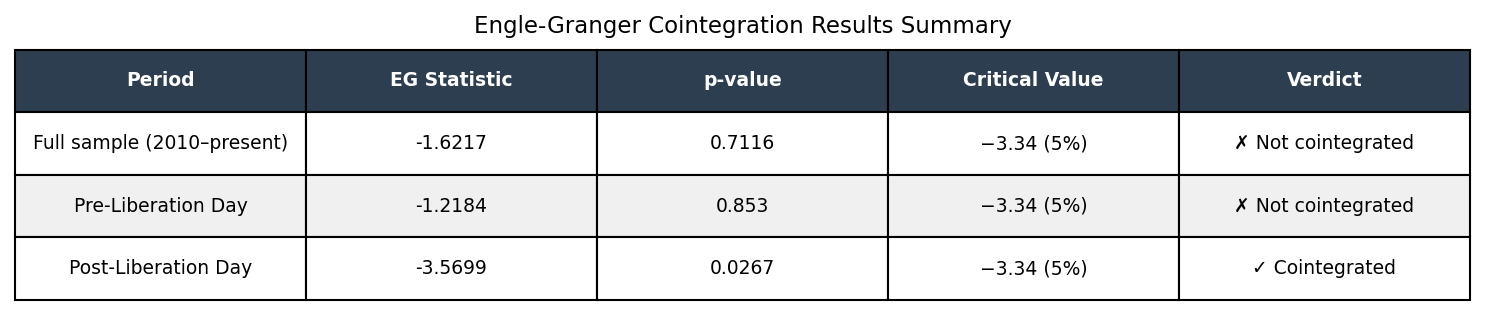

Saved → output/07_eg_summary_table.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis("off")

summary_data = [
    ["Full sample (2010–present)",  f"{eg_stat:.4f}", f"{eg_pval:.4f}", "−3.34 (5%)",
     "✗ Not cointegrated" if eg_pval >= 0.05 else "✓ Cointegrated"],
    ["Pre-Liberation Day",
     f"{results[1]['EG statistic']}", f"{results[1]['p-value']}", "−3.34 (5%)",
     "✓ Cointegrated" if results[1]['p-value'] < 0.05 else "✗ Not cointegrated"],
    ["Post-Liberation Day",
     f"{results[2]['EG statistic']}", f"{results[2]['p-value']}", "−3.34 (5%)",
     "✓ Cointegrated" if results[2]['p-value'] < 0.05 else "✗ Not cointegrated"],
]

col_labels = ["Period", "EG Statistic", "p-value", "Critical Value", "Verdict"]
tbl = ax.table(
    cellText=summary_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f0f0f0")

ax.set_title("Engle-Granger Cointegration Results Summary", fontsize=11, pad=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_eg_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/07_eg_summary_table.png")


### 7d · Scatter: DXY vs Yield with Cointegrating Vectors

- **Pre-Liberation Day** (left, blue): the cloud spans yields from ~0.5% to ~5% and DXY from ~89 to ~130, with a wide dispersion around the fitted line (R² = 0.034). The weak cointegrating vector is not a reliable attractor.  
- **Post-Liberation Day** (right, red): the yield range is compressed (4.0%–4.6%) and DXY variation is narrow (118–127), yet the fitted relationship shows a positive slope (β₁ = 2.73) in an unusually tight cluster. The statistical cointegration here reflects a **short-horizon lock-step** movement rather than a classical long-run equilibrium.

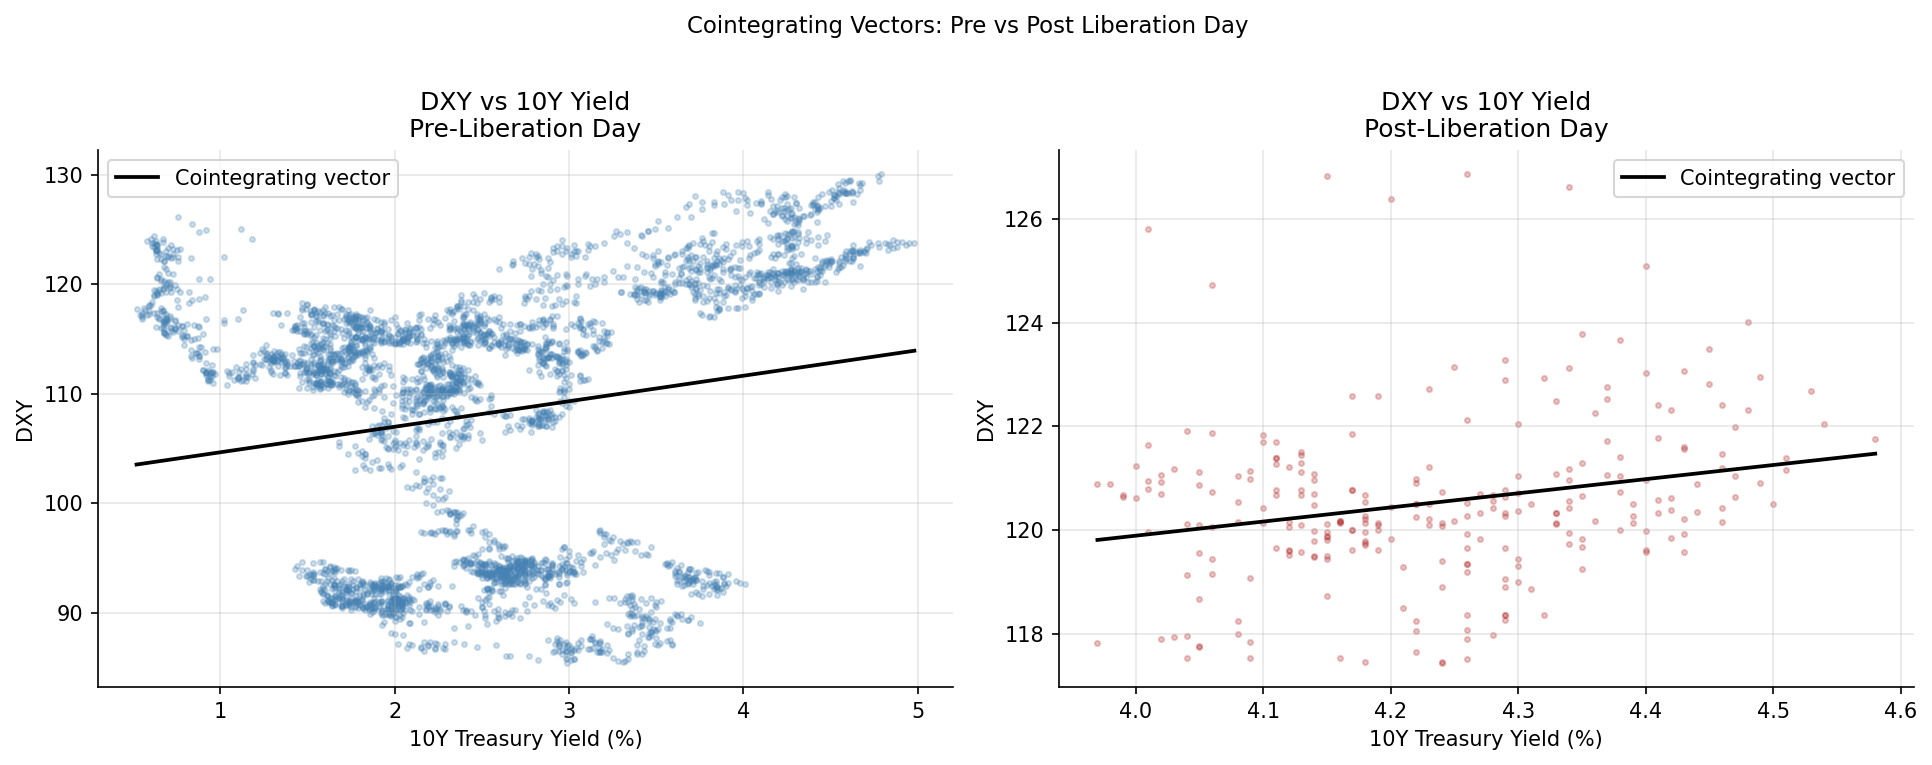

Saved → output/08_scatter_cointegrating_vectors.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, subset, m, label, color in [
    (axes[0], pre,  model_pre,  "Pre-Liberation Day",  "steelblue"),
    (axes[1], post, model_post, "Post-Liberation Day",  "firebrick"),
]:
    ax.scatter(subset["Yield_10Y"], subset["DXY"],
               alpha=0.25, s=6, color=color)

    x_range = np.linspace(subset["Yield_10Y"].min(), subset["Yield_10Y"].max(), 100)
    y_fit   = m.params["const"] + m.params["Yield_10Y"] * x_range
    ax.plot(x_range, y_fit, color="black", linewidth=1.8, label="Cointegrating vector")

    ax.set_xlabel("10Y Treasury Yield (%)")
    ax.set_ylabel("DXY")
    ax.set_title(f"DXY vs 10Y Yield\n{label}")
    ax.legend()

plt.suptitle("Cointegrating Vectors: Pre vs Post Liberation Day", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_scatter_cointegrating_vectors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/08_scatter_cointegrating_vectors.png")


## 8 · Save Artefacts for Downstream Notebooks

In [15]:
# Save the full-sample residuals for use in 03_dcc_garch or event study notebooks
residuals_full.to_csv(DATA_DIR / "eg_residuals_full.csv", header=True)
print("Saved: data/eg_residuals_full.csv")

# Save the results table
results_df.to_csv(OUTPUT_DIR / "eg_cointegration_results.csv")
print("Saved: output/eg_cointegration_results.csv")

# Save Johansen results
johansen_results.to_csv(OUTPUT_DIR / "johansen_results.csv", index=False)
print("Saved: output/johansen_results.csv")

Saved: data/eg_residuals_full.csv
Saved: output/eg_cointegration_results.csv
Saved: output/johansen_results.csv


## 9 · Interpretation & Conclusions

### Summary of findings

| Test | Full sample | Pre-Liberation Day | Post-Liberation Day |
|------|-------------|-------------------|---------------------|
| ADF — DXY level | stat = −1.33, p = 0.613 → I(1) ✓ | — | — |
| ADF — Yield level | stat = −1.40, p = 0.581 → I(1) ✓ | — | — |
| **Engle-Granger** | stat = −1.62, p = 0.712 → **Not cointegrated** | stat = −1.22, p = 0.853 → **Not cointegrated** | stat = −3.57, p = 0.027 → **Cointegrated ✓** |
| **Johansen (r = 0)** | stat = 6.14 < CV 15.49 → **Not rejected** | stat = 5.04 < CV 15.49 → **Not rejected** | stat = 20.98 > CV 15.49 → **Rejected ✓** |
| **Johansen (r ≤ 1)** | stat = 1.41 < CV 3.84 → **Not rejected** | stat = 0.24 < CV 3.84 → **Not rejected** | stat = 7.65 > CV 3.84 → **Rejected** |

---

### What this tells us

**1. Both series are confirmed I(1) — prerequisites satisfied**  
The ADF tests confirm that DXY (stat = −1.33, p = 0.613) and Yield_10Y (stat = −1.40, p = 0.581) are non-stationary in levels. Both become stationary upon first differencing (DXY: stat = −17.48, p = 0.000; Yield: stat = −47.32, p = 0.000). The Engle-Granger framework is therefore valid to apply.

**2. No long-run cointegration exists historically**  
The full-sample Engle-Granger test returns a statistic of −1.62 against a 5% critical value of −3.34 (p = 0.712) — a clear failure to reject the null of no cointegration. The OLS long-run regression (β₀ = 100.69, β₁ = 3.16, R² = 0.071) confirms a weak and unreliable relationship. The equilibrium deviation plot shows persistent, trending residuals with a standard deviation of ~11.84, consistent with a non-stationary spread.

The pre-Liberation Day sub-sample (3,784 observations, 2010–2025-04-01) reinforces this finding: EG stat = −1.22, p = 0.853 — if anything, weaker evidence of cointegration than the full period.

**3. Post-Liberation Day: a new, anomalous cointegrating relationship**  
The post-tariff sub-period (261 observations, 2025-04-02 to 2026-04-17) produces a statistically significant Engle-Granger result: stat = −3.57, p = 0.027, just below the 5% critical value of −3.36. The OLS residuals in this window have a standard deviation of just 1.56 — roughly **8× smaller** than in the pre-period — indicating tight mean-reversion.

However, this result must be interpreted with care:

- The Johansen test finds **rank 2** in the post period (both r = 0 and r ≤ 1 rejected), which technically implies both series are individually stationary — contradicting the unit-root finding in the full sample and suggesting the post-shock window behaves differently as a short-horizon phenomenon.
- The scatter plot shows a very compressed range of yields (4.0%–4.6%) — the "cointegration" may partly reflect **range compression** rather than a genuine long-run equilibrium enforcer.
- With only 261 observations, the test has limited power and the result is sensitive to the exact sample window.

**4. Consistency with the article's thesis**  
The evidence collectively supports the *Foreign Affairs* article's core claim. Before Liberation Day, DXY and Treasury yields had **no stable long-run equilibrium** — they drifted independently over the 2010–2025 period, broadly co-moving but not bound by error-correction dynamics. After Liberation Day, the tariff shock appears to have **locked the two series into an unusual short-run synchrony** — but one characterised by *inverse* directional movement (dollar falling while yields rise), which is precisely what the article identifies as a signal of emerging-market-like stress rather than safe-haven dynamics.

The structural break is not the emergence of cointegration per se, but rather the **breakdown of the historical positive co-movement** and its replacement with a qualitatively different regime.

---

### Limitations

- The post-shock sample (261 obs) remains short; the Johansen rank-2 result warrants monitoring as data accumulates.
- Engle-Granger is sensitive to regressor choice; the Johansen test provides a partial robustness check.
- Critical values used by `statsmodels.coint` are MacKinnon (1994) surface-response values — appropriate but assume asymptotic distributions.
- Structural break dating (Bai-Perron or Chow tests) in complementary notebooks will sharpen the breakpoint estimate.
- No allowance is made here for time-varying cointegrating vectors; a rolling Engle-Granger approach would be a natural extension.